In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq
from scipy.optimize import curve_fit
import glob
import xarray as xr
from matplotlib.dates import YearLocator, DateFormatter

# Load the GPS data
file_path = 'HYDE.tenv3' 

# Reading the columns for the date and verical displacement 
data = pd.read_csv(
    file_path,
    sep=r'\s+',              
    header=None,             
    skiprows=1,              
    usecols=[2, 12],          
    names=['decimal_year', 'vertical'],  
    comment='#'            
)

# Drop NaNs 
data = data.dropna()

t = data['decimal_year'].values
y = data['vertical'].values

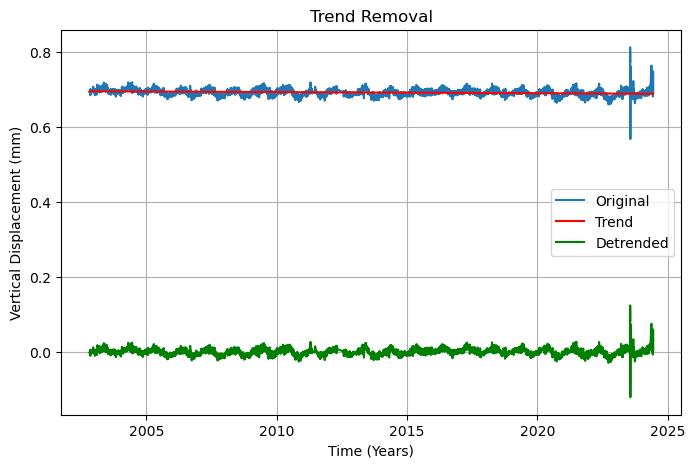

In [32]:
#Remove Linear Trend
def linear(t, a, b):
    return a * t + b

lin_params, _ = curve_fit(linear, t, y)
y_detrended = y - linear(t, *lin_params)

plt.figure(figsize=(8, 5))
plt.plot(t, y, label='Original')
plt.plot(t, linear(t, *lin_params), label='Trend', color='red')
plt.plot(t, y_detrended, label='Detrended', color='green')
plt.legend()
plt.title('Trend Removal')
plt.xlabel('Time (Years)')
plt.ylabel('Vertical Displacement (mm)')
plt.grid() 
plt.show()

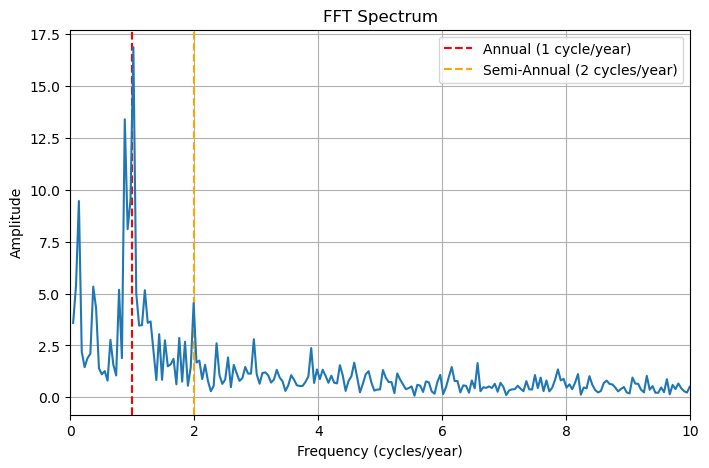

In [33]:
#FFT Analysis
N = len(t)
dt = (t[-1] - t[0]) / N
freqs = fftfreq(N, dt)
fft_vals = fft(y_detrended)
amplitudes = np.abs(fft_vals)

pos_freqs = freqs[freqs > 0]
pos_amps = amplitudes[freqs > 0]

plt.figure(figsize=(8, 5))
plt.axvline(1, color='r', linestyle='--', label='Annual (1 cycle/year)')
plt.axvline(2, color='orange', linestyle='--', label='Semi-Annual (2 cycles/year)')
plt.plot(pos_freqs, pos_amps)
plt.xlim(0, 10)
plt.xlabel('Frequency (cycles/year)')
plt.ylabel('Amplitude')
plt.title('FFT Spectrum')
plt.grid(True)
plt.legend()
plt.show()

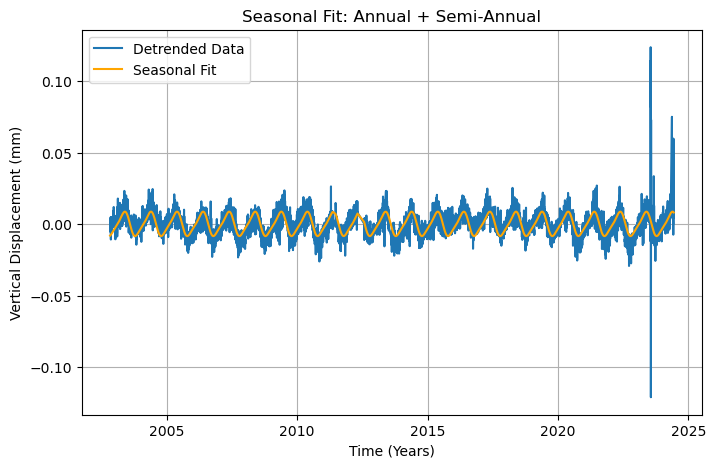

In [34]:
#seasonal least squares fit annual + semi annual
def seasonal_model(t, A1, phi1, A2, phi2):
    return (A1 * np.cos(2 * np.pi * t + phi1) +
            A2 * np.cos(4 * np.pi * t + phi2))

params, _ = curve_fit(seasonal_model, t, y_detrended)
y_fit = seasonal_model(t, *params)

plt.figure(figsize=(8, 5))
plt.plot(t, y_detrended, label='Detrended Data')
plt.plot(t, y_fit, label='Seasonal Fit', color='orange')
plt.legend()
plt.title('Seasonal Fit: Annual + Semi-Annual')
plt.xlabel('Time (Years)')
plt.ylabel('Vertical Displacement (mm)')
plt.grid()
plt.show()

In [125]:
#loading the rainfall data from 2003 to 2019
file_list = sorted(glob.glob('data/cum_*.nc'))

# Open and concatenate along time dimension
ds = xr.open_mfdataset(file_list, combine='by_coords')
#print(ds)

In [156]:
# GPS station coordinates 
lat_gps = 17.3850
lon_gps = 78.4867
# Select nearest grid point
rain_ts = ds['tp'].sel(lat=lat_gps, lon=lon_gps, method='nearest')

# Convert to pandas Series 
rain_monthly = rain_ts.to_series().dropna()

rain_monthly.index = pd.to_datetime(rain_monthly.index)

In [157]:
#for converting GPS data
def decimal_year_to_datetime(decimal_year):
    try:
        year = int(decimal_year)
        if year <= 0 or year > 2100:
            return pd.NaT
        remainder = decimal_year - year
        start = pd.Timestamp(year=year, month=1, day=1)
        end = pd.Timestamp(year=year + 1, month=1, day=1)
        seconds = remainder * (end - start).total_seconds()
        return start + pd.to_timedelta(seconds, unit='s')
    except:
        return pd.NaT

In [158]:
#reading in the gps data with panda 
gps_data = pd.read_csv('HYDE.tenv3',sep='\s+',skiprows=1,header=None,usecols=[1, 2, 8, 10, 12, 14, 15, 16] )
gps_data.columns = ['Year', 'DOY','East', 'North','Up', 'Sig_East', 'Sig_North','Sig_Up']


# Convert 
gps_data['Date'] = gps_data['DOY'].apply(decimal_year_to_datetime)
gps_data = gps_data.set_index('Date')
gps_monthly = gps_data['Up'].resample('ME').mean().dropna()
#rain_monthly = rain_monthly.resample('ME').mean().dropna()

In [159]:
gps_up = gps_data['Up'].dropna()
gps_monthly.index = gps_monthly.index.to_period('M').to_timestamp()
rain_monthly.index = rain_monthly.index.to_period('M').to_timestamp()

# Align
common_index = gps_monthly.index.intersection(rain_monthly.index)
gps_aligned = gps_monthly.loc[common_index]
rain_aligned = rain_monthly.loc[common_index]

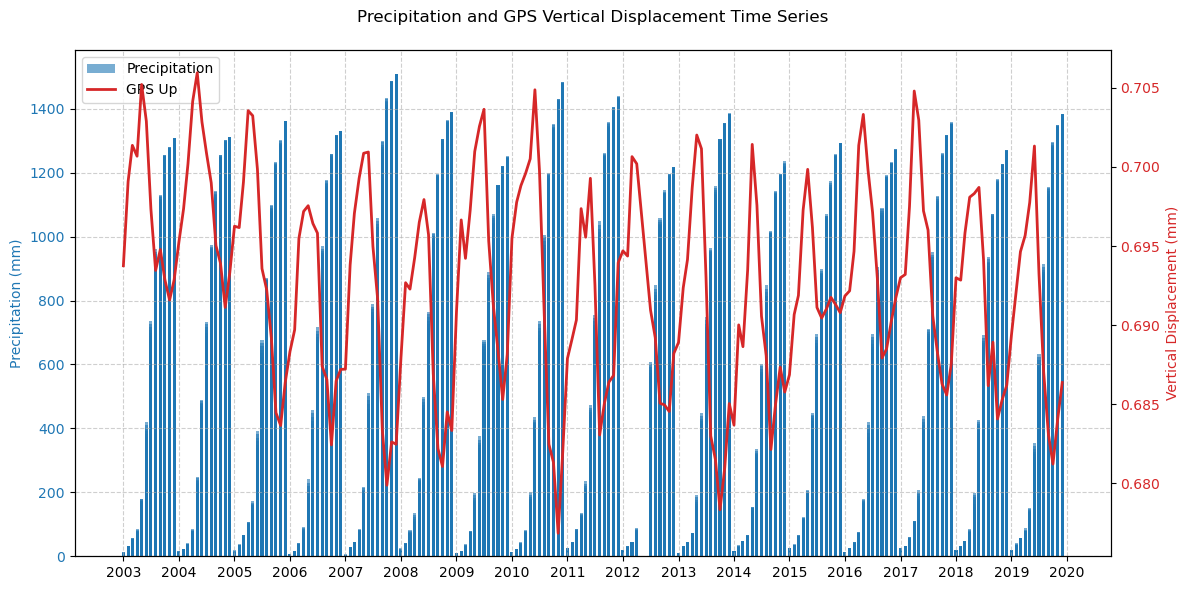

In [160]:
    plt.figure(figsize=(12, 6))
    
    # Plot precipitation
    ax1 = plt.gca()
    color = 'tab:blue'
    ax1.set_ylabel('Precipitation (mm)', color=color)
    bars = ax1.bar(rain_aligned.index, rain_aligned, width=20, 
                   color=color, alpha=0.6, label='Precipitation')
    ax1.tick_params(axis='y', labelcolor=color)
    
    # Plot GPS 
    ax2 = ax1.twinx()
    color = 'tab:red'
    ax2.set_ylabel('Vertical Displacement (mm)', color=color)
    line = ax2.plot(gps_aligned.index, gps_aligned, 
                   color=color, linewidth=2, label='GPS Up')
    ax2.tick_params(axis='y', labelcolor=color)
    
    # Format x-axis
    ax1.xaxis.set_major_locator(YearLocator()) 
    ax1.xaxis.set_major_formatter(DateFormatter('%Y'))
    plt.xticks(rotation=0) 
    
    lines = [bars, line[0]]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left')
    
    
    plt.title('Precipitation and GPS Vertical Displacement Time Series', pad=20)
    ax1.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.savefig("percipitation_VS_GPS.png")
plt.show()

In [151]:
correlation = gps_monthly.corr(rain_monthly)
print(f"Correlation between GPS vertical displacement and Rainfall: {correlation:.3f}")

Correlation between GPS vertical displacement and Rainfall: -0.669


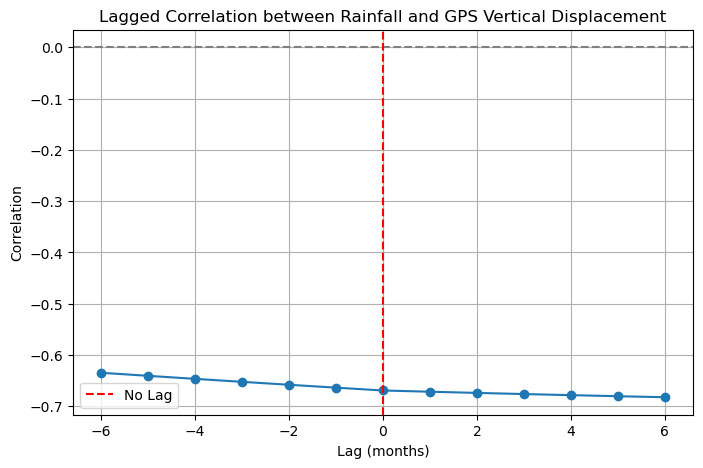

In [152]:
#Compute lagged correlations
lags = range(-6, 7)
correlations = []

for lag in lags:
    shifted_rain = rain_monthly.shift(lag)
    corr = gps_monthly.corr(shifted_rain)
    correlations.append(corr)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(lags, correlations, marker='o')
plt.axhline(0, color='gray', linestyle='--')
plt.axvline(0, color='red', linestyle='--', label='No Lag')
plt.title('Lagged Correlation between Rainfall and GPS Vertical Displacement')
plt.xlabel('Lag (months)')
plt.ylabel('Correlation')
plt.grid(True)
plt.legend()
plt.savefig("lagged_correlation.png")
plt.show()

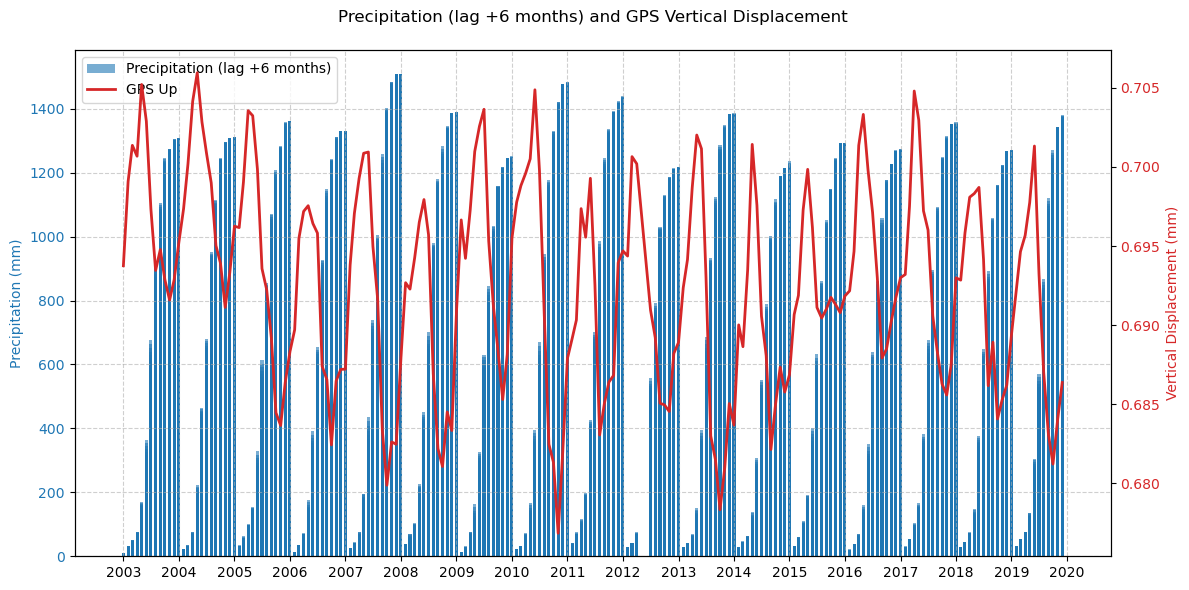

In [146]:
lag_months = 6
rain_lagged = rain_aligned.shift(lag_months)

plt.figure(figsize=(12, 6))

# Plot lagged precipitation
ax1 = plt.gca()
color = 'tab:blue'
ax1.set_ylabel('Precipitation (mm)', color=color)
bars = ax1.bar(rain_lagged.index, rain_lagged, width=20, 
               color=color, alpha=0.6, label=f'Precipitation (lag +{lag_months} months)')
ax1.tick_params(axis='y', labelcolor=color)

# Plot GPS 
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Vertical Displacement (mm)', color=color)
line = ax2.plot(gps_aligned.index, gps_aligned, 
               color=color, linewidth=2, label='GPS Up')
ax2.tick_params(axis='y', labelcolor=color)

# Format x-axis
ax1.xaxis.set_major_locator(YearLocator()) 
ax1.xaxis.set_major_formatter(DateFormatter('%Y'))
plt.xticks(rotation=0) 

lines = [bars, line[0]]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left')

plt.title(f'Precipitation (lag +{lag_months} months) and GPS Vertical Displacement', pad=20)
ax1.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("precipitation_vs_GPS_lagged.png")
plt.show()


In [147]:
correlation2 = gps_aligned.corr(rain_lagged)
print(f"Correlation between GPS vertical displacement and Rainfall: {correlation2:.3f}")

Correlation between GPS vertical displacement and Rainfall: -0.682
